In [ ]:
# Boston Rental Market Analysis

# Exploratory Data Analysis & ML Price Predictions

#Datasets: 500 Boston rental listings across 15+ neighborhoods
#Goal: Identify best value rentals, analyze neighborhood pricings, and uncover factors that drive rent prices in Boston

In [1]:
#1. Setup & Data Loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from io import StringIO
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print('Libraries loaded successfully!')

C:\Users\manal\AppData\Roaming\Python\Python310\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Libraries loaded successfully!


In [5]:
# Load dataset (handles the quoted CSV format)
with open("C:\\Users\\manal\\Downloads\\Projects\\boston_rentals_with_predictions.xls.csv", 'r', encoding='utf-8-sig') as f:
    content = f.read()

lines = content.split('\n')
cleaned = '\n'.join(line.strip('"') for line in lines if line.strip())
df = pd.read_csv(StringIO(cleaned))

print(f'Dataset loaded: {df.shape[0]} listings, {df.shape[1]} columns')
df.head()

Dataset loaded: 500 listings, 28 columns


,listing_id,neighborhood,price,bedrooms,bathrooms,sqft,price_per_sqft,mbta_line,distance_to_mbta_miles,distance_to_harvard_miles,...,furnished,broker_fee,available_date,days_on_market,predicted_price,price_difference,price_difference_pct,deal_score,listing_category,amenity_score
0,BOS100000,Cambridge,6769,4,2.5,1266,5.35,Red,0.14,4.23,...,False,0.5-month,2025-09-01,14,7251.746602,-482.746602,-6.656970,-6.656970,Good Deal,7
1,BOS100001,Brighton,2650,1,1.0,764,3.47,Green,0.05,15.27,...,False,none,2025-09-01,8,2654.877845,-4.877845,-0.183731,-0.183731,Fair Price,3
2,BOS100002,Back Bay,5150,2,1.0,865,5.95,Orange,0.04,4.44,...,False,1-month,2025-09-01,26,4609.138240,540.861760,11.734553,11.734553,Very Overpriced,2
3,BOS100003,Charlestown,2668,1,1.0,460,5.80,Orange,0.13,5.07,...,False,none,2025-07-01,14,2740.048602,-72.048602,-2.629464,-2.629464,Fair Price,2
4,BOS100004,South End,2449,0,1.0,361,6.78,Orange,0.12,1.10,...,False,0.5-month,2025-09-01,8,2456.315509,-7.315509,-0.297824,-0.297824,Fair Price,0


In [8]:
# 2. Data Overview
# Basic info
print('=== DATASET INFO ===')
print(f'Total Listings: {len(df)}')
print(f'Neighborhoods: {df["neighborhood"].nunique()}')
print(f'Average Rent: ${df["price"].mean():,.0f}/month')
print(f'Price Range: ${df["price"].min():,} - ${df["price"].max():,}')
print(f'Missing Values: {df.isnull().sum().sum()}')
print()
print('=== LISTING CATEGORIES ===')
print(df['listing_category'].value_counts())

=== DATASET INFO ===
Total Listings: 500
Neighborhoods: 16
Average Rent: $3,711/month
Price Range: $1,325 - $8,093
Missing Values: 0

=== LISTING CATEGORIES ===
listing_category
Fair Price         426
Good Deal           31
Very Overpriced     17
Excellent Deal      16
Overpriced          10
Name: count, dtype: int64


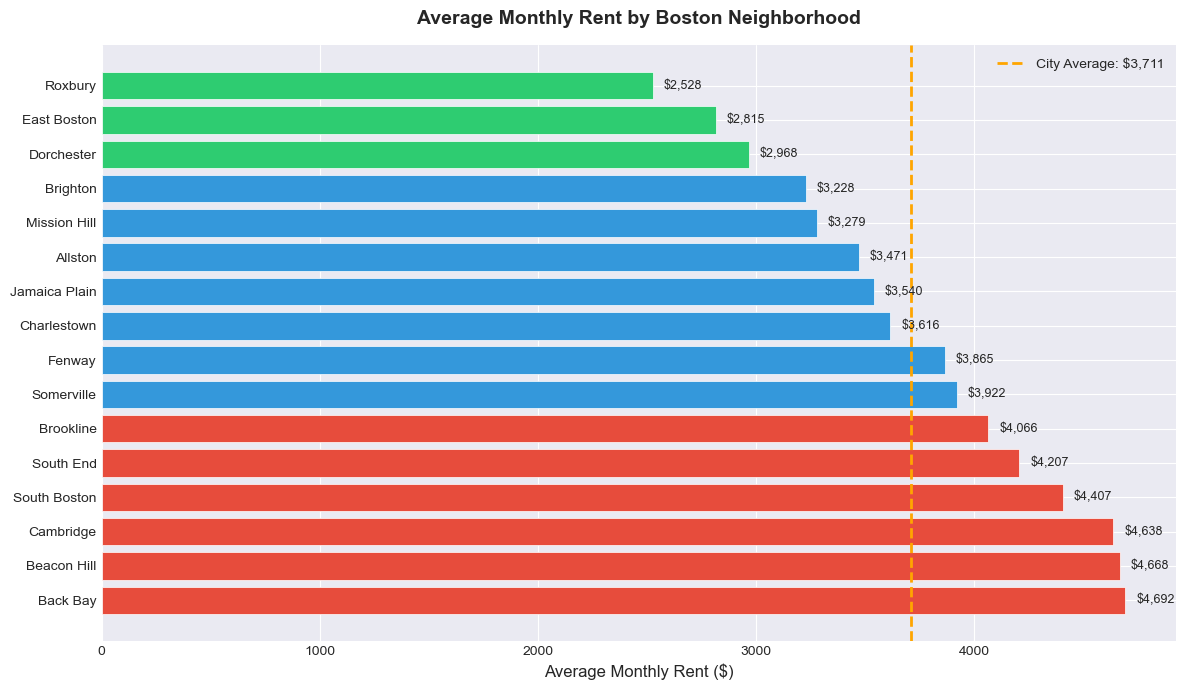

Most expensive: Back Bay ($4,692/mo)
Most affordable: Roxbury ($2,528/mo)


In [11]:
#3 Analysis 1- Average Rent by Neighborhood
# Average rent by neighborhood
neighborhood_avg = df.groupby('neighborhood')['price'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 7))
colors = ['#e74c3c' if p > 4000 else '#3498db' if p > 3000 else '#2ecc71' for p in neighborhood_avg.values]
bars = ax.barh(neighborhood_avg.index, neighborhood_avg.values, color=colors, edgecolor='white', linewidth=0.5)

# Add value labels
for bar, val in zip(bars, neighborhood_avg.values):
    ax.text(val + 50, bar.get_y() + bar.get_height()/2, f'${val:,.0f}', va='center', fontsize=9)

ax.set_xlabel('Average Monthly Rent ($)', fontsize=12)
ax.set_title('Average Monthly Rent by Boston Neighborhood', fontsize=14, fontweight='bold', pad=15)
ax.axvline(df['price'].mean(), color='orange', linestyle='--', linewidth=2, label=f'City Average: ${df["price"].mean():,.0f}')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('avg_rent_by_neighborhood.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Most expensive: {neighborhood_avg.index[0]} (${neighborhood_avg.iloc[0]:,.0f}/mo)')
print(f'Most affordable: {neighborhood_avg.index[-1]} (${neighborhood_avg.iloc[-1]:,.0f}/mo)')

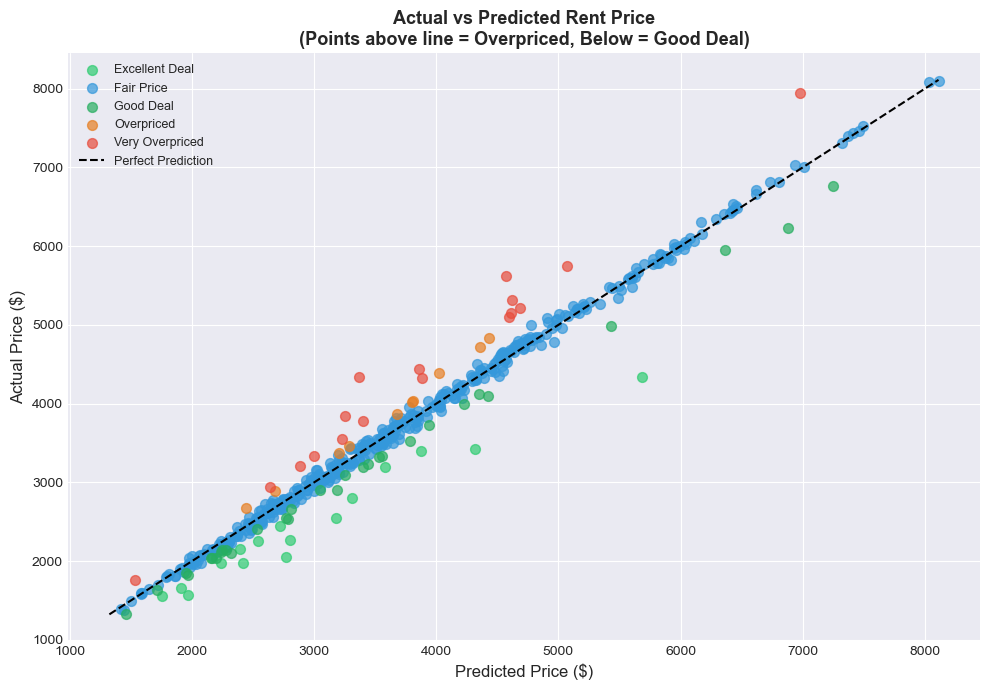

In [14]:
#4  Analysis 2 - Actual Price vs Predicted Price
# Actual vs Predicted price scatter plot
fig, ax = plt.subplots(figsize=(10, 7))

colors_map = {'Excellent Deal': '#2ecc71', 'Good Deal': '#27ae60', 
              'Fair Price': '#3498db', 'Overpriced': '#e67e22', 'Very Overpriced': '#e74c3c'}
for category, group in df.groupby('listing_category'):
    ax.scatter(group['predicted_price'], group['price'], 
               c=colors_map.get(category, 'grey'), label=category, alpha=0.7, s=50)

# Perfect prediction line
min_val = min(df['price'].min(), df['predicted_price'].min())
max_val = max(df['price'].max(), df['predicted_price'].max())
ax.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1.5, label='Perfect Prediction')

ax.set_xlabel('Predicted Price ($)', fontsize=12)
ax.set_ylabel('Actual Price ($)', fontsize=12)
ax.set_title('Actual vs Predicted Rent Price\n(Points above line = Overpriced, Below = Good Deal)', 
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

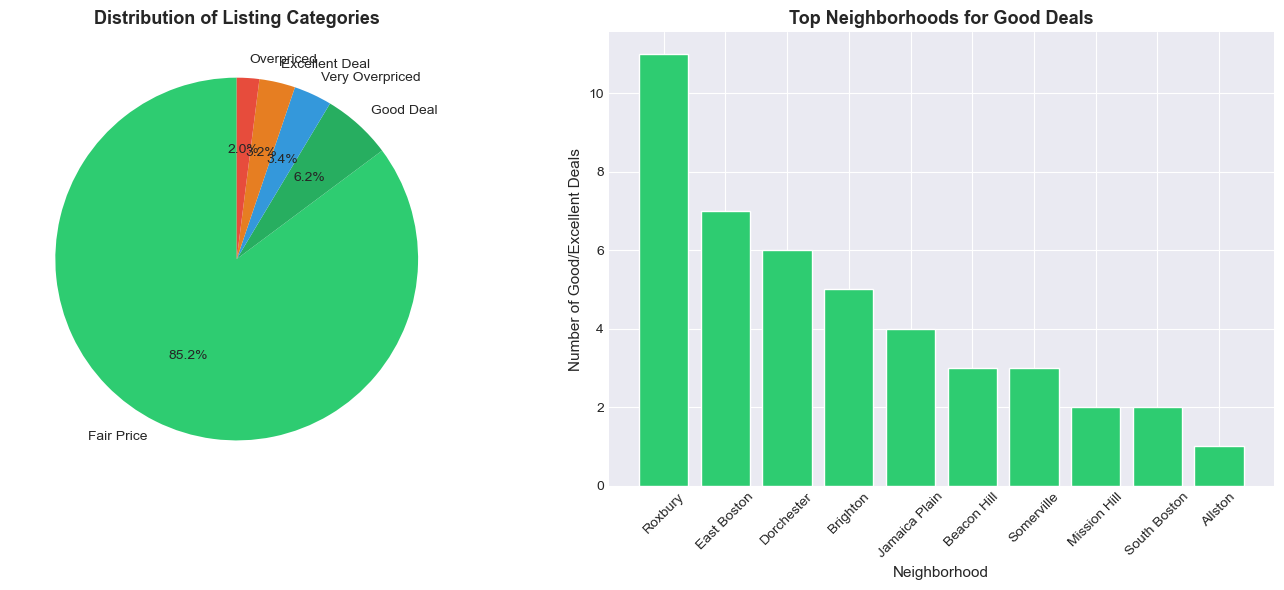

Good/Excellent Deals: 47 listings (9.4%)
Overpriced listings: 27 listings


In [17]:
#5 Analysis 3 - Deal Score Distribution by Neighborhood
# Deal category distribution
deal_counts = df['listing_category'].value_counts()
colors_pie = ['#2ecc71', '#27ae60', '#3498db', '#e67e22', '#e74c3c']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart
ax1.pie(deal_counts.values, labels=deal_counts.index, colors=colors_pie, 
        autopct='%1.1f%%', startangle=90, textprops={'fontsize': 10})
ax1.set_title('Distribution of Listing Categories', fontsize=13, fontweight='bold')

# Best deal neighborhoods
good_deals = df[df['listing_category'].isin(['Good Deal', 'Excellent Deal'])]
good_by_neighborhood = good_deals.groupby('neighborhood').size().sort_values(ascending=False).head(10)
ax2.bar(good_by_neighborhood.index, good_by_neighborhood.values, color='#2ecc71', edgecolor='white')
ax2.set_xlabel('Neighborhood', fontsize=11)
ax2.set_ylabel('Number of Good/Excellent Deals', fontsize=11)
ax2.set_title('Top Neighborhoods for Good Deals', fontsize=13, fontweight='bold')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('deal_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Good/Excellent Deals: {len(good_deals)} listings ({len(good_deals)/len(df)*100:.1f}%)')
print(f'Overpriced listings: {len(df[df["listing_category"].isin(["Overpriced","Very Overpriced"])])} listings')

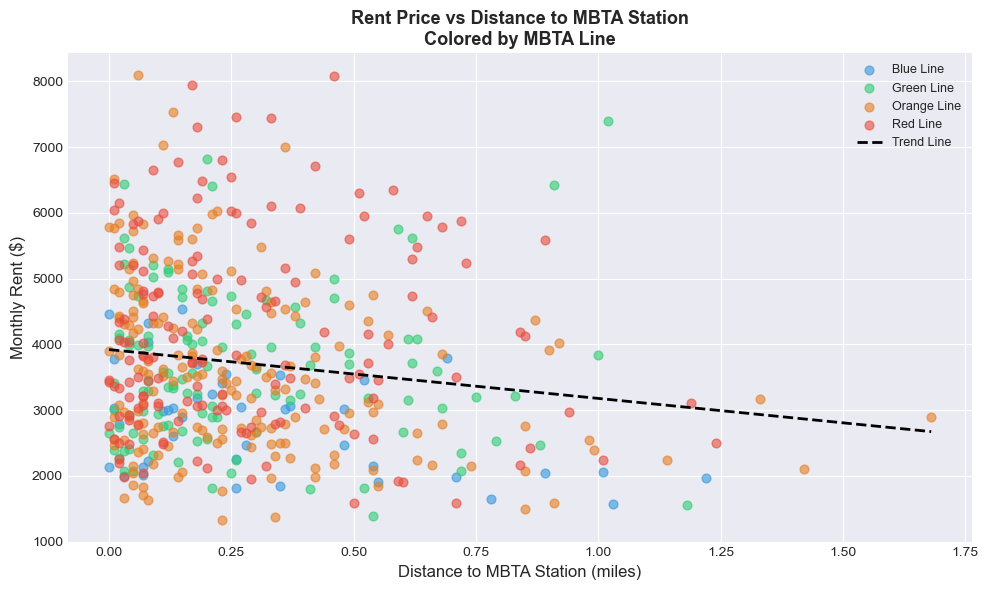

Correlation between MBTA distance and rent: -0.151


In [19]:
#6. Analysis 4 - Rent vs Distance to MBTA
# Rent vs distance to MBTA
fig, ax = plt.subplots(figsize=(10, 6))

mbta_colors = {'Red': '#e74c3c', 'Green': '#2ecc71', 'Orange': '#e67e22', 'Blue': '#3498db', 'Silver': '#95a5a6'}
for line, group in df.groupby('mbta_line'):
    ax.scatter(group['distance_to_mbta_miles'], group['price'], 
               c=mbta_colors.get(line, 'grey'), label=f'{line} Line', alpha=0.6, s=40)

# Trend line
z = np.polyfit(df['distance_to_mbta_miles'], df['price'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['distance_to_mbta_miles'].min(), df['distance_to_mbta_miles'].max(), 100)
ax.plot(x_line, p(x_line), 'k--', linewidth=2, label='Trend Line')

ax.set_xlabel('Distance to MBTA Station (miles)', fontsize=12)
ax.set_ylabel('Monthly Rent ($)', fontsize=12)
ax.set_title('Rent Price vs Distance to MBTA Station\nColored by MBTA Line', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
plt.tight_layout()
plt.savefig('rent_vs_mbta.png', dpi=150, bbox_inches='tight')
plt.show()

corr = df['distance_to_mbta_miles'].corr(df['price'])
print(f'Correlation between MBTA distance and rent: {corr:.3f}')

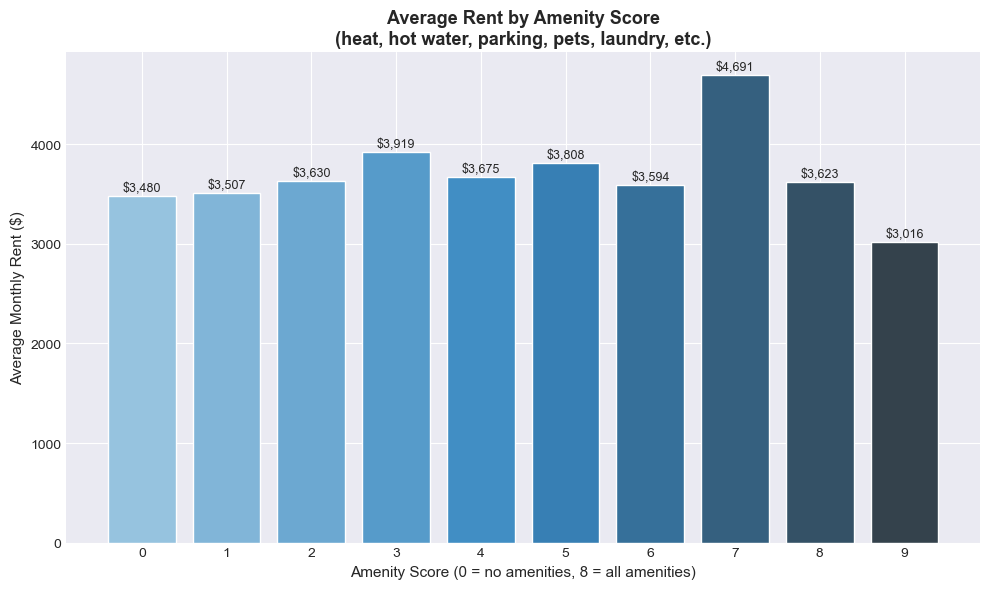

Correlation between amenity score and rent: 0.098


In [21]:
#7. Analysis 5 - Amenity Score vs Price
# Amenity score vs price
amenity_avg = df.groupby('amenity_score')['price'].mean()

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(amenity_avg.index, amenity_avg.values, color=sns.color_palette('Blues_d', len(amenity_avg)), edgecolor='white')
for i, (score, val) in enumerate(amenity_avg.items()):
    ax.text(score, val + 50, f'${val:,.0f}', ha='center', fontsize=9)

ax.set_xlabel('Amenity Score (0 = no amenities, 8 = all amenities)', fontsize=11)
ax.set_ylabel('Average Monthly Rent ($)', fontsize=11)
ax.set_title('Average Rent by Amenity Score\n(heat, hot water, parking, pets, laundry, etc.)', fontsize=13, fontweight='bold')
ax.set_xticks(amenity_avg.index)
plt.tight_layout()
plt.savefig('amenity_vs_price.png', dpi=150, bbox_inches='tight')
plt.show()

corr = df['amenity_score'].corr(df['price'])
print(f'Correlation between amenity score and rent: {corr:.3f}')

In [23]:
#8. Key Findings Summary
print('=' * 60)
print('BOSTON RENTAL MARKET — KEY FINDINGS')
print('=' * 60)

most_expensive = df.groupby('neighborhood')['price'].mean().idxmax()
most_affordable = df.groupby('neighborhood')['price'].mean().idxmin()
best_deal_hood = df[df['listing_category'].isin(['Good Deal','Excellent Deal'])].groupby('neighborhood').size().idxmax()
good_deals_count = len(df[df['listing_category'].isin(['Good Deal','Excellent Deal'])])
overpriced_count = len(df[df['listing_category'].isin(['Overpriced','Very Overpriced'])])

print(f'1. Average rent across Boston: ${df["price"].mean():,.0f}/month')
print(f'2. Most expensive neighborhood: {most_expensive} (${df.groupby("neighborhood")["price"].mean()[most_expensive]:,.0f}/mo)')
print(f'3. Most affordable neighborhood: {most_affordable} (${df.groupby("neighborhood")["price"].mean()[most_affordable]:,.0f}/mo)')
print(f'4. Good/Excellent deals: {good_deals_count} listings ({good_deals_count/len(df)*100:.1f}% of market)')
print(f'5. Overpriced listings: {overpriced_count} listings ({overpriced_count/len(df)*100:.1f}% of market)')
print(f'6. Best neighborhood for deals: {best_deal_hood}')
print(f'7. MBTA distance correlation with rent: {df["distance_to_mbta_miles"].corr(df["price"]):.3f}')
print(f'8. Amenity score correlation with rent: {df["amenity_score"].corr(df["price"]):.3f}')
print('=' * 60)

BOSTON RENTAL MARKET — KEY FINDINGS
1. Average rent across Boston: $3,711/month
2. Most expensive neighborhood: Back Bay ($4,692/mo)
3. Most affordable neighborhood: Roxbury ($2,528/mo)
4. Good/Excellent deals: 47 listings (9.4% of market)
5. Overpriced listings: 27 listings (5.4% of market)
6. Best neighborhood for deals: Roxbury
7. MBTA distance correlation with rent: -0.151
8. Amenity score correlation with rent: 0.098
